In [114]:
import uuid
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import AIMessage, RemoveMessage
from langgraph.graph.message import add_messages

# 1. State definition me add_messages reducer specify karein
class State(TypedDict):
    query: str
    drop: bool
    messages: Annotated[list, add_messages]  # Reducer zaroori hai

def add_message(state: State)->State:
    """Message create karte waqt unique ID assign karein."""
    new_message = AIMessage(
        content=state["query"], 
        id=str(uuid.uuid4())  # Unique ID add ki
    )
    return {"messages": [new_message]}

def remove_message(state: State)->State:
    """Pehle 2 messages ko state se delete karta hai."""
    if not state["drop"]:
        return state
    
    # State se pehle 2 messages uthaye
    messages_to_remove = state["messages"][:2]
    
    # RemoveMessage objects generate karein (jinme id present ho)
    delete_messages = [
        RemoveMessage(id=m.id) 
        for m in messages_to_remove 
        if m.id is not None
    ]
    
    return {"messages": delete_messages}

In [115]:
from langgraph.graph import START,END,StateGraph

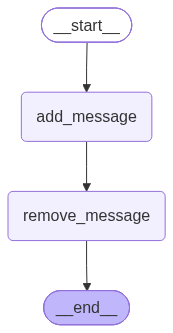

In [116]:
graph = StateGraph(State)

graph.add_node("add_message", add_message)
graph.add_node("remove_message", remove_message)
graph.add_edge(START, "add_message")
graph.add_edge("add_message", "remove_message")
graph.add_edge("remove_message", END)
graph = graph.compile(checkpointer=InMemorySaver())

graph

In [128]:
graph.invoke({"messages": [], "query": "Hello, World!2","drop":False}, config={"configurable": {"thread_id": "1"}})

{'query': 'Hello, World!2',
 'drop': False,
 'messages': [AIMessage(content='Hello, World!2', additional_kwargs={}, response_metadata={}, id='00f3eb38-c6f7-47a6-a0b8-03aa1fa1f997', tool_calls=[], invalid_tool_calls=[])]}

In [127]:
graph.invoke({"messages": [], "query": "Hello, World!2","drop":True}, config={"configurable": {"thread_id": "1"}})

{'query': 'Hello, World!2', 'drop': True, 'messages': []}

In [12]:
state["messages"]=[SystemMessage(content="Hello, World!")]

In [13]:
state

{'messages': [SystemMessage(content='Hello, World!', additional_kwargs={}, response_metadata={})]}

In [14]:
state["messages"]=[AIMessage(content="Hello, World!2")]

In [15]:
state

{'messages': [AIMessage(content='Hello, World!2', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]}